In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv("Downloads/_2017_Yellow_Taxi_Trip_Data.csv")

df.head()

,ID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,3/25/2017 8:55,3/25/2017 9:09,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,4/11/2017 14:53,4/11/2017 15:19,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26,12/15/2017 7:34,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,5/7/2017 13:17,5/7/2017 13:48,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,4/15/2017 23:32,4/15/2017 23:49,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


 ## 3 Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [4]:
df.shape

(22699, 18)

In [5]:
df.columns

Index(['ID', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount'],
      dtype='object')

## 4️⃣ Missing Values

In [6]:
df.isnull().sum()

ID                       0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

## 5 Descriptive Statistics

In [7]:
df.describe()

,ID,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


In [8]:
df.groupby("payment_type")["fare_amount"].mean()

payment_type
1    13.429748
2    12.213546
3    12.186116
4     9.913043
Name: fare_amount, dtype: float64

### Note: In the dataset, payment_type is encoded in integers:

1: Credit card

2: Cash

3: No charge

4: Dispute

5: Unknown

Based on the averages shown, it appears that customers who pay in credit card tend to pay a larger fare amount than customers who pay in cash. However, this difference might arise from random sampling, rather than being a true difference in fare amount. To assess whether the difference is statistically significant, I conduct a hypothesis test.

### visulization 

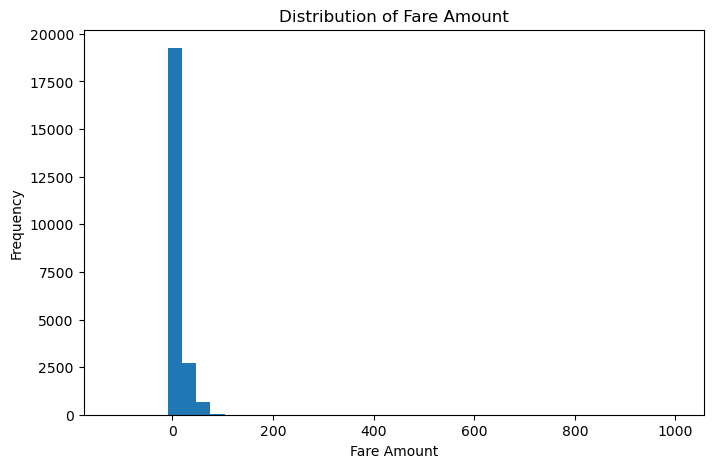

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["fare_amount"], bins=40)

plt.title("Distribution of Fare Amount")

plt.xlabel("Fare Amount")

plt.ylabel("Frequency")

plt.show()

Insight

Most taxi fares are between $5–$20.

---

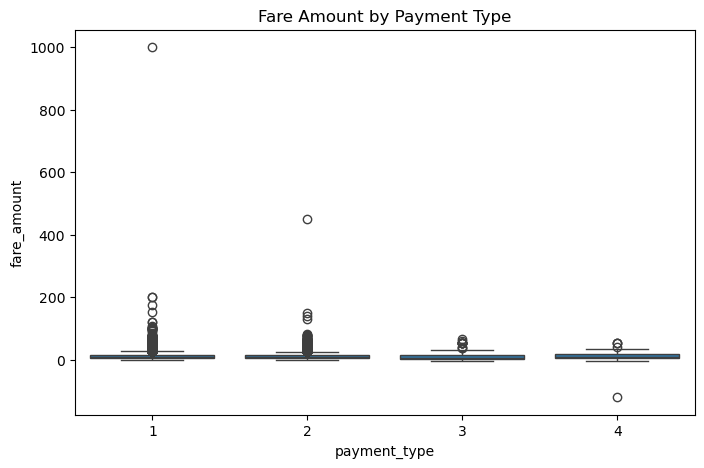

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x="payment_type",
            y="fare_amount",
            data=df)

plt.title("Fare Amount by Payment Type")

plt.show()

Insight

Credit card users generally pay higher fares than cash users.

---

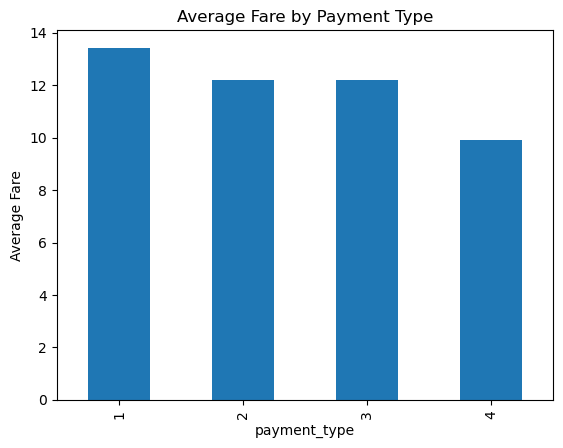

In [12]:
avg=df.groupby("payment_type")["fare_amount"].mean()

avg.plot(kind="bar")

plt.title("Average Fare by Payment Type")

plt.ylabel("Average Fare")

plt.show()

Insight

Average fare is highest for Credit Card payments.

 ---

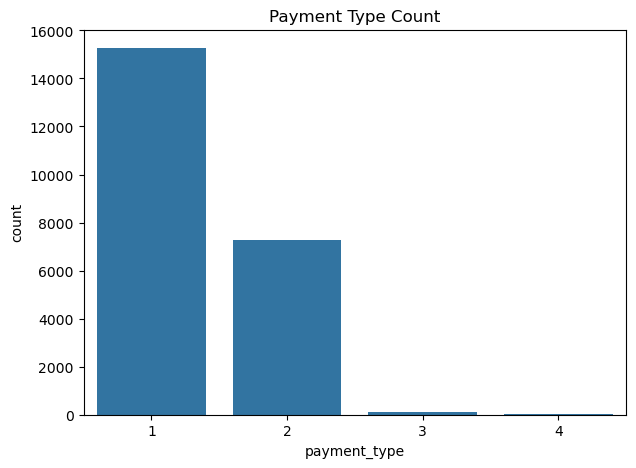

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(x="payment_type",
              data=df)

plt.title("Payment Type Count")

plt.show()

Insight

Most customers use Credit Cards.

---

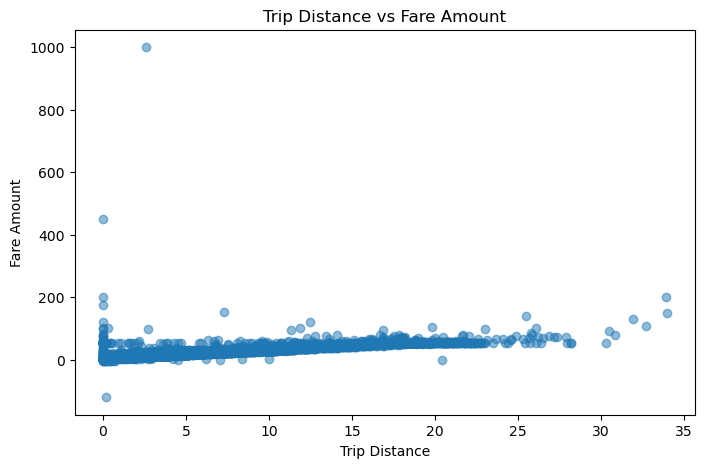

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df["trip_distance"],
            df["fare_amount"],
            alpha=0.5)

plt.xlabel("Trip Distance")

plt.ylabel("Fare Amount")

plt.title("Trip Distance vs Fare Amount")

plt.show()

Insight

Longer trips generally result in higher fares

----
# hypothesis Testing (Two Sample T-Test)
### Step 1

### Null Hypothesis

There is no difference in average fare amount between Credit Card and Cash payments.

### Alternative Hypothesis

There is a difference in average fare amount between Credit Card and Cash payments.

### Step 2

Significance Level

In [16]:
alpha=0.05

### Step 3

Create Groups

In [17]:
credit=df[df["payment_type"]==1]["fare_amount"]

cash=df[df["payment_type"]==2]["fare_amount"]

### Step 4

Run T-Test

In [18]:
t_stat,p_value=stats.ttest_ind(
    credit,
    cash,
    equal_var=False
)

print(t_stat)

print(p_value)

6.866800855655361
6.7973874730310106e-12


### Step 5 Decision

In [19]:
if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


---
### Business Insight

- Credit card users pay higher average fares than cash users.
- The difference is statistically significant.
- Digital payment customers often take longer or more expensive trips.
- Payment method is associated with fare amount.

### Recommendation
- Encourage digital payments.
- Offer cashback or card discounts.
- Promote cashless payments.
- Further investigate trip distance and tipping behavior.
- Build predictive fare models using additional features.